In [23]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

df = pd.read_csv('diabetes.csv')


X = df.drop(columns=['Class']).values
y = (df['Class'] == 'positive').astype(float).values  # positive -> 1, negative -> 0

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
df.shape

(768, 8)

In [24]:
# Define the model (7 input features in this dataset)
model = nn.Sequential(
    nn.Linear(7, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)


Sequential(
  (0): Linear(in_features=7, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


In [25]:
#THis part to Run only the first layer directly

with torch.no_grad():
    out1 = model[0](X)

print(out1.shape)             # torch.Size([768, 12]) -> 12 values per patient
print(out1[0])                # first patient's 12 raw outputs

torch.Size([768, 12])
tensor([ -1.5348,  -0.5495, -51.6470,  62.1181, -17.2785, -56.1523,  26.5639,
        -30.0714, -12.2997, -27.7183,  -8.7392,  19.2497])


In [26]:
# First layer directly with  ReLU

with torch.no_grad():
    out1_relu = model[:2](X)  # Linear(7,12) -> ReLU
print(out1_relu[0])           # same 12 values but negatives clipped to 0

tensor([ 0.0000,  0.0000,  0.0000, 62.1181,  0.0000,  0.0000, 26.5639,  0.0000,
         0.0000,  0.0000,  0.0000, 19.2497])


In [27]:
# one layer at a time

x = X[0:1]                    # first patient (keep 2D shape: [1, 7])

with torch.no_grad():
    for layer in model:
        x = layer(x)
        print(f"{layer.__class__.__name__:>8}: {x.numpy().round(3)}")

  Linear: [[ -1.535  -0.55  -51.647  62.118 -17.279 -56.152  26.564 -30.071 -12.3
  -27.718  -8.739  19.25 ]]
    ReLU: [[ 0.     0.     0.    62.118  0.     0.    26.564  0.     0.     0.
   0.    19.25 ]]
  Linear: [[ 3.036  4.559 19.881 -7.493 -1.575 -2.066 21.051 -1.512]]
    ReLU: [[ 3.036  4.559 19.881  0.     0.     0.    21.051  0.   ]]
  Linear: [[-3.97]]
 Sigmoid: [[0.019]]


In [28]:
# Forward Pass
with torch.no_grad():
    out_relu = model[:2](X)   # runs model[0] (Linear) then model[1] (ReLU)

print(out_relu.shape)         # torch.Size([768, 12])
print(out_relu[0])            # first patient's 12 activations after ReLU

torch.Size([768, 12])
tensor([ 0.0000,  0.0000,  0.0000, 62.1181,  0.0000,  0.0000, 26.5639,  0.0000,
         0.0000,  0.0000,  0.0000, 19.2497])


In [29]:
# Train the model
loss_fn = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 100
batch_size = 10

In [36]:
for epoch in range(n_epochs):
    for i in range(0, len(X), batch_size):
        Xbatch = X[i:i + batch_size]
        y_pred = model(Xbatch)
        ybatch = y[i:i + batch_size]
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Finished epoch {epoch}, latest loss {loss}')

Finished epoch 0, latest loss 0.655038595199585
Finished epoch 1, latest loss 0.6093839406967163
Finished epoch 2, latest loss 0.5624462366104126
Finished epoch 3, latest loss 0.5354386568069458
Finished epoch 4, latest loss 0.5176090598106384
Finished epoch 5, latest loss 0.5293450951576233
Finished epoch 6, latest loss 0.4973709285259247
Finished epoch 7, latest loss 0.4997140169143677
Finished epoch 8, latest loss 0.49764537811279297
Finished epoch 9, latest loss 0.5009222626686096
Finished epoch 10, latest loss 0.5039687752723694
Finished epoch 11, latest loss 0.49791669845581055
Finished epoch 12, latest loss 0.5008313059806824
Finished epoch 13, latest loss 0.49259668588638306
Finished epoch 14, latest loss 0.496670126914978
Finished epoch 15, latest loss 0.5011367201805115
Finished epoch 16, latest loss 0.5066442489624023
Finished epoch 17, latest loss 0.4973655939102173
Finished epoch 18, latest loss 0.4982011318206787
Finished epoch 19, latest loss 0.4955343008041382
Finished 

In [31]:
def train_with_lr(lr, n_epochs=20, batch_size=10):
    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(7,12), nn.ReLU(), nn.Linear(12,8), nn.ReLU(),
                      nn.Linear(8,1), nn.Sigmoid())
    opt = optim.Adam(m.parameters(), lr=lr)
    loss_fn = nn.BCELoss()

    history = []
    for epoch in range(n_epochs):
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, len(X), batch_size):
            y_pred = m(X[i:i+batch_size])
            loss = loss_fn(y_pred, y[i:i+batch_size])
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item(); n_batches += 1
        history.append(epoch_loss / n_batches)

    with torch.no_grad():
        accuracy = (m(X).round() == y).float().mean().item()
    return history, accuracy

In [32]:
results = {lr: train_with_lr(lr) for lr in [5.0, 1e-7, 0.001]}


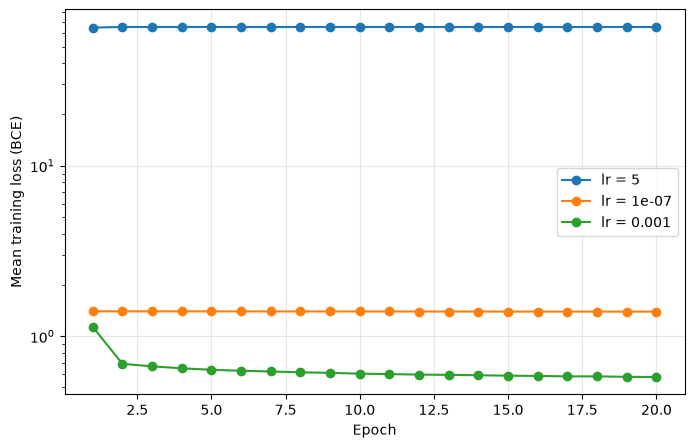

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for lr, (history, _) in results.items():
    plt.plot(range(1, len(history)+1), history, marker='o', label=f'lr = {lr:g}')
plt.xlabel('Epoch'); plt.ylabel('Mean training loss (BCE)')
plt.yscale('log'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Compute accuracy (no_grad is optional)
with torch.no_grad():
    y_pred = model(X)
accuracy = (y_pred.round() == y).float().mean()
print(f"Accuracy {accuracy}")

Accuracy 0.6302083134651184


saved


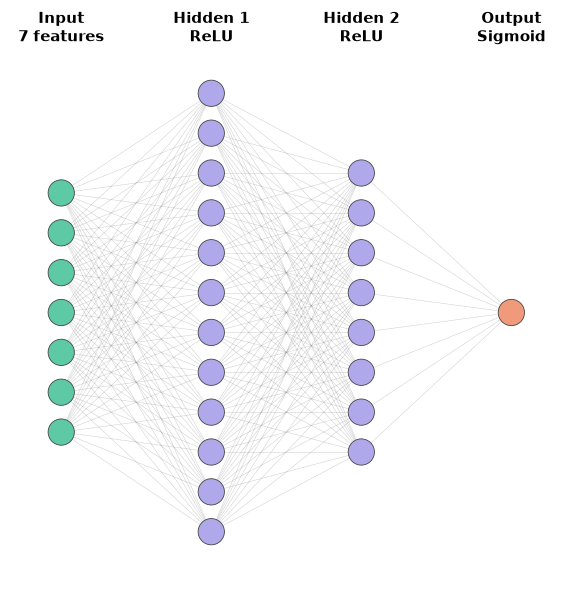

In [35]:
import matplotlib.pyplot as plt

def draw_network(layer_sizes, layer_labels=None, layer_colors=None,
                 node_r=0.28, x_gap=3.2, y_gap=0.85, save_as=None):
    """Draw a fully-connected neural network as circles and lines."""
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.set_aspect('equal'); ax.axis('off')

    if layer_colors is None:
        layer_colors = ['#5DCAA5'] + ['#AFA9EC'] * (len(layer_sizes) - 2) + ['#F0997B']

    # Compute node positions (each layer vertically centered)
    positions = []
    for i, n in enumerate(layer_sizes):
        x = i * x_gap
        ys = [(j - (n - 1) / 2) * y_gap for j in range(n)]
        positions.append([(x, y) for y in ys])

    # Connections first (so circles draw on top)
    for a, b in zip(positions[:-1], positions[1:]):
        for (x1, y1) in a:
            for (x2, y2) in b:
                ax.plot([x1, x2], [y1, y2], color='gray',
                        linewidth=0.4, alpha=0.35, zorder=1)

    # Neurons
    for pts, color in zip(positions, layer_colors):
        for (x, y) in pts:
            ax.add_patch(plt.Circle((x, y), node_r, facecolor=color,
                                    edgecolor='#444', linewidth=0.6, zorder=2))

    # Labels above each layer
    if layer_labels:
        top = max(len(n) for n in positions) * 0  # noqa
        y_top = max(max(y for _, y in pts) for pts in positions) + 1.0
        for i, label in enumerate(layer_labels):
            ax.text(i * x_gap, y_top, label, ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

    ax.autoscale()
    ax.margins(0.08)
    if save_as:
        fig.savefig(save_as, dpi=200, bbox_inches='tight')
    return fig, ax


if __name__ == '__main__':
    draw_network(
        layer_sizes=[7, 12, 8, 1],
        layer_labels=['Input\n7 features', 'Hidden 1\nReLU', 'Hidden 2\nReLU', 'Output\nSigmoid'],
        save_as='NN1.png'
    )
    print('saved')